<a href="https://colab.research.google.com/github/Swastik058/AI-ML/blob/main/2438468_SwastikAcharya_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Dataset**

In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/"  # adjust path if inside a folder

train_df = pd.read_csv("/content/drive/MyDrive/5. Movie Review Dataset/train_movie_review.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/5. Movie Review Dataset/test_movie_review.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/5. Movie Review Dataset/val_movie_review.csv")

# Drop unnamed index column
train_df = train_df[['review', 'sentiment']]
test_df  = test_df[['review',  'sentiment']]
val_df   = val_df[['review',   'sentiment']]

# Drop any rows where sentiment is null (unlabeled data)
train_df.dropna(subset=['sentiment'], inplace=True)
test_df.dropna(subset=['sentiment'],  inplace=True)
val_df.dropna(subset=['sentiment'],   inplace=True)

print(f"Train: {train_df.shape} | Test: {test_df.shape} | Val: {val_df.shape}")
print("\nLabel Distribution - Train:")
print(train_df['sentiment'].value_counts())
print("\nSample Review:\n", train_df['review'].iloc[0][:300])

Train: (35000, 2) | Test: (10000, 2) | Val: (5000, 2)

Label Distribution - Train:
sentiment
0    17584
1    17416
Name: count, dtype: int64

Sample Review:
 Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl


**Install Required Libraries**

In [ ]:
!pip install nltk wordcloud contractions
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**WordCloud Uncleaned**

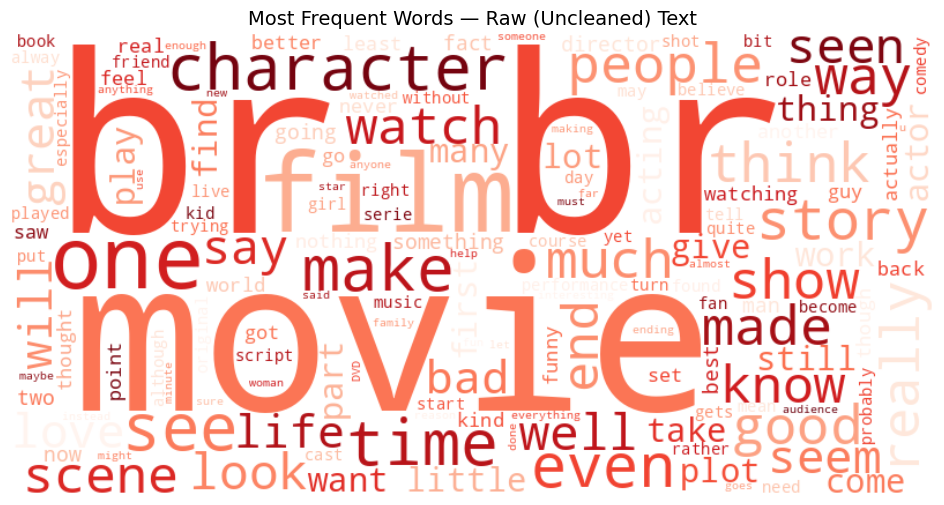

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

raw_text = ' '.join(train_df['review'])

wordcloud_raw = WordCloud(width=800, height=400,
                          background_color='white',
                          max_words=150,
                          colormap='Reds').generate(raw_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words — Raw (Uncleaned) Text", fontsize=14)
plt.show()

**Top 20 Most Frequent Words Uncleaned**

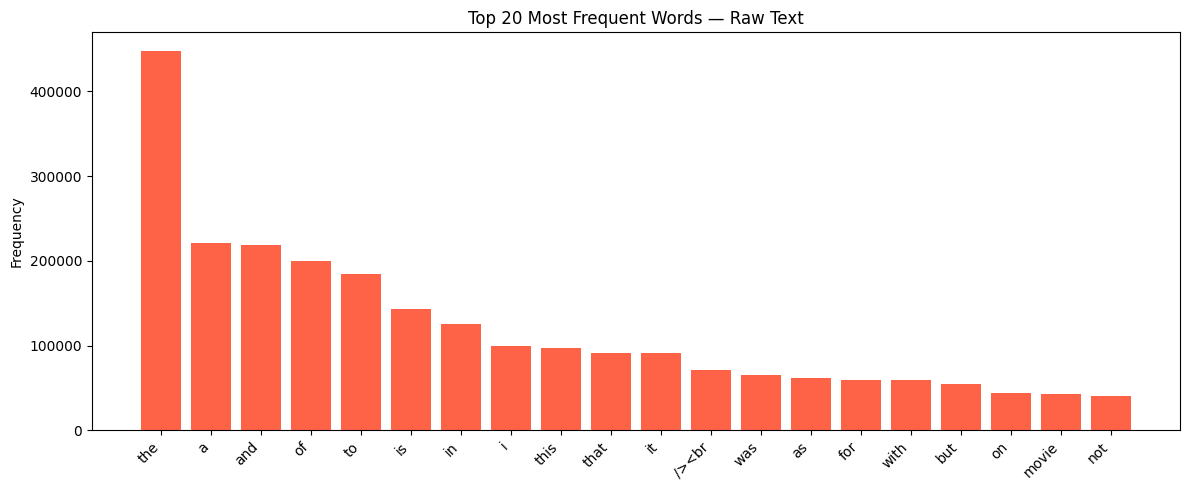

In [ ]:
from collections import Counter

raw_words = ' '.join(train_df['review']).lower().split()
raw_freq = Counter(raw_words).most_common(20)

words_r, counts_r = zip(*raw_freq)
plt.figure(figsize=(12, 5))
plt.bar(words_r, counts_r, color='tomato')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Words — Raw Text")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Text Cleaning**

In [ ]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Expand contractions (don't → do not)
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply to all splits
train_df['cleaned'] = train_df['review'].apply(clean_text)
test_df['cleaned']  = test_df['review'].apply(clean_text)
val_df['cleaned']   = val_df['review'].apply(clean_text)

print("Sample cleaned review:")
print(train_df['cleaned'].iloc[0][:300])

Sample cleaned review:
avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed accordi


#**Visualize Cleaned Data**

**WordCloud Cleaned**

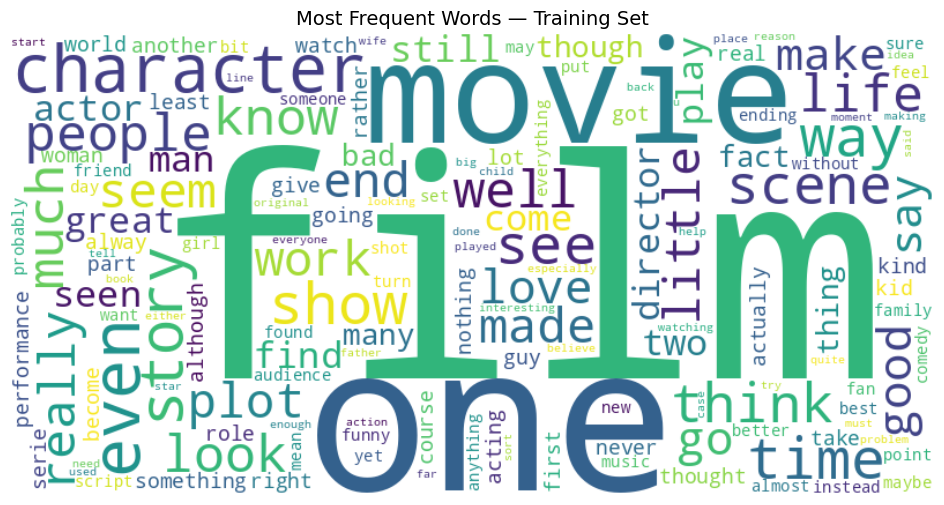

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(train_df['cleaned'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=150,
                      colormap='viridis').generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words — Training Set", fontsize=14)
plt.show()

**Top 20 Most Frequent Words Cleaned**

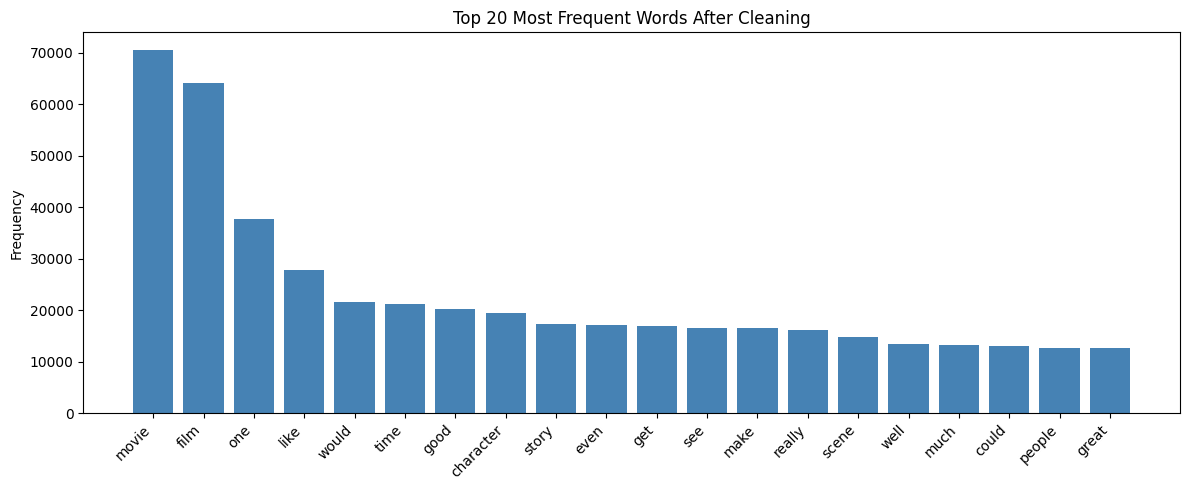

In [ ]:
from collections import Counter

all_words = ' '.join(train_df['cleaned']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Top 20 Words Side-by-Side Bar Chart**

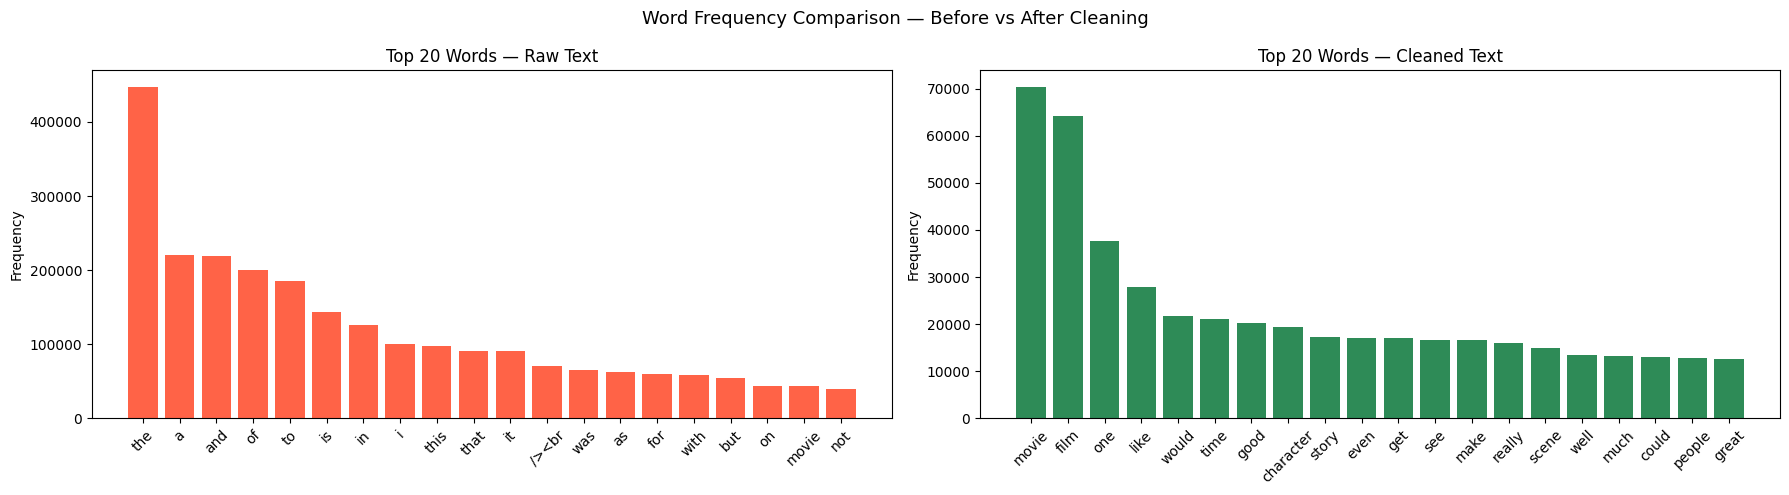

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Raw
raw_top = Counter(' '.join(train_df['review']).lower().split()).most_common(20)
w_r, c_r = zip(*raw_top)
axes[0].bar(w_r, c_r, color='tomato')
axes[0].set_title("Top 20 Words — Raw Text")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=45)

# Cleaned
clean_top = Counter(' '.join(train_df['cleaned']).split()).most_common(20)
w_c, c_c = zip(*clean_top)
axes[1].bar(w_c, c_c, color='seagreen')
axes[1].set_title("Top 20 Words — Cleaned Text")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Word Frequency Comparison — Before vs After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

**Sentiment Distribution**

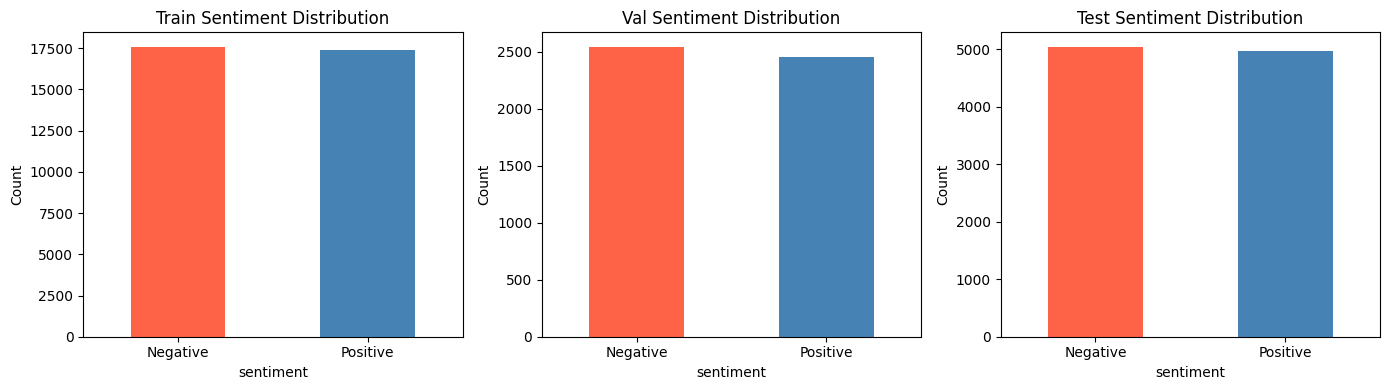

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, name) in zip(axes, [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]):
    df['sentiment'].value_counts().plot(kind='bar', ax=ax,
                                         color=['tomato','steelblue'])
    ax.set_title(f"{name} Sentiment Distribution")
    ax.set_xticklabels(['Negative','Positive'], rotation=0)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Tokenization & Padding**

95th percentile sequence length: 301
Mean: 117 | Max: 1416 | Min: 4


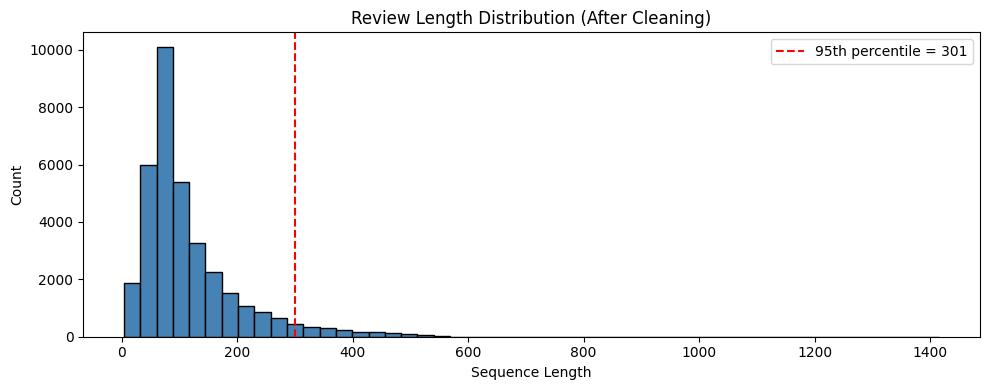


X_train shape: (35000, 301)
X_val shape:   (5000, 301)
X_test shape:  (10000, 301)


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Fit tokenizer on training data only
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'])

# Convert to sequences
X_train = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test  = tokenizer.texts_to_sequences(test_df['cleaned'])

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

# Percentile-based padding length
lengths = [len(seq) for seq in X_train]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"95th percentile sequence length: {MAX_LEN}")
print(f"Mean: {np.mean(lengths):.0f} | Max: {np.max(lengths)} | Min: {np.min(lengths)}")

# Plot sequence length distribution
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title("Review Length Distribution (After Cleaning)")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Apply padding
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train shape: {X_train_pad.shape}")
print(f"X_val shape:   {X_val_pad.shape}")
print(f"X_test shape:  {X_test_pad.shape}")

**Model 1:  Simple RNN with Trainable Embedding**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

EMBED_DIM = 64

model_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)
rnn_time = time.time() - start
print(f"RNN Training time: {rnn_time:.2f}s")

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4997 - loss: 0.7023 - val_accuracy: 0.5002 - val_loss: 0.7008
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4986 - loss: 0.7007 - val_accuracy: 0.4914 - val_loss: 0.7008
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4966 - loss: 0.6970 - val_accuracy: 0.4982 - val_loss: 0.6943
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5026 - loss: 0.6955 - val_accuracy: 0.4906 - val_loss: 0.6951
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5032 - loss: 0.6951 - val_accuracy: 0.4910 - val_loss: 0.6963
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4974 - loss: 0.6950 - val_accuracy: 0.4910 - val_loss: 0.6936
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5003 - loss: 0.6944 - val_accuracy: 0.5094 - val_loss: 0.6933
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4985 - loss: 0.6942 - 

**Plot**

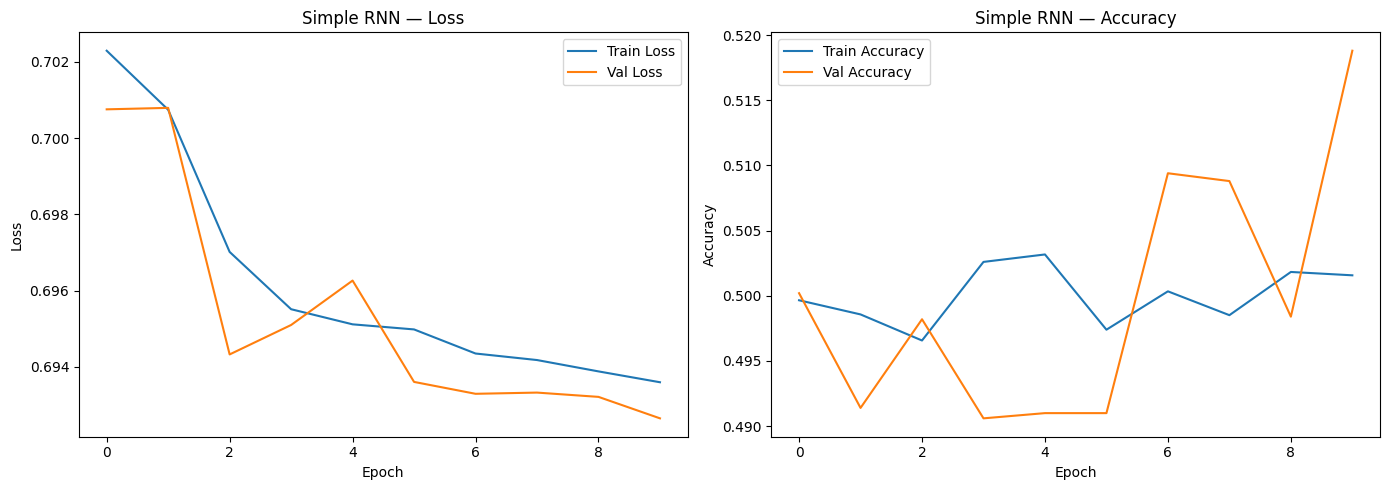

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['loss'],     label='Train Loss')
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss')
axes[0].set_title("Simple RNN — Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history_rnn.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("Simple RNN — Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
=== Simple RNN — Test Evaluation ===

              precision    recall  f1-score   support

    Negative       0.51      0.36      0.42      4961
    Positive       0.51      0.66      0.57      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



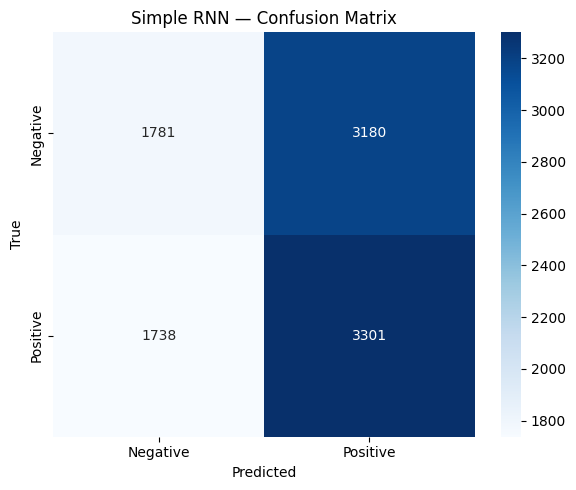

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

y_pred_rnn = (model_rnn.predict(X_test_pad) > 0.5).astype(int)

print("=== Simple RNN — Test Evaluation ===\n")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Simple RNN — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

**Model 2: LSTM**

In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)
lstm_time = time.time() - start
print(f"LSTM Training time: {lstm_time:.2f}s")

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5067 - loss: 0.6931 - val_accuracy: 0.4942 - val_loss: 0.6934
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.5147 - loss: 0.6856 - val_accuracy: 0.4998 - val_loss: 0.7023
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5245 - loss: 0.6706 - val_accuracy: 0.5008 - val_loss: 0.6977
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5298 - loss: 0.6620 - val_accuracy: 0.4944 - val_loss: 0.7454
LSTM Training time: 45.39s


**Plot**

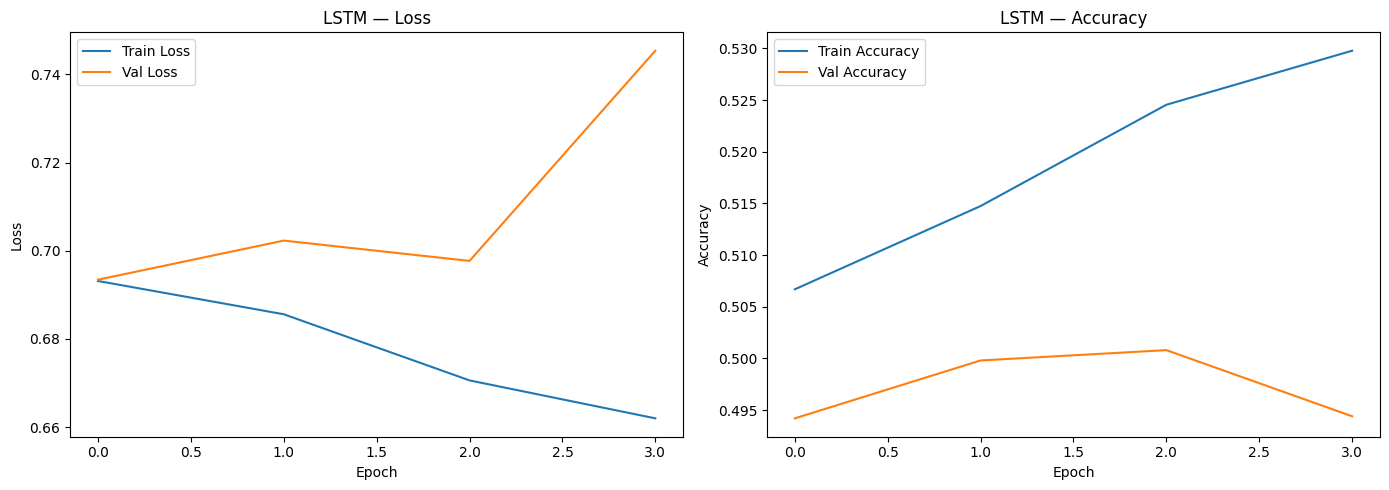

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'],     label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[0].set_title("LSTM — Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("LSTM — Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate**

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== LSTM — Test Evaluation ===

              precision    recall  f1-score   support

    Negative       0.50      0.95      0.65      4961
    Positive       0.55      0.06      0.10      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.38     10000
weighted avg       0.52      0.50      0.38     10000



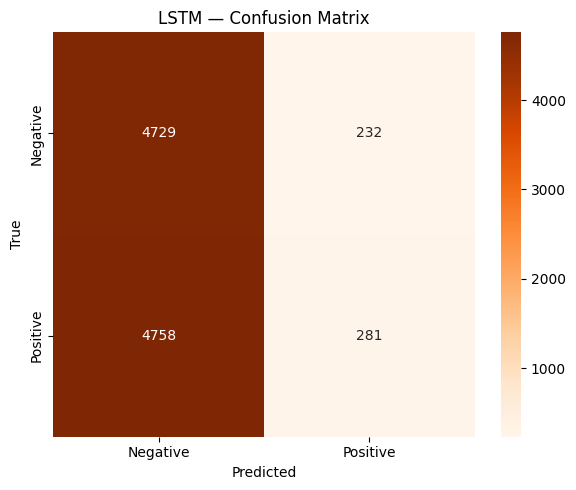

In [ ]:
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

print("=== LSTM — Test Evaluation ===\n")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("LSTM — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

**Model 2 with Bidirectional LSTM**

In [ ]:
from tensorflow.keras.layers import Bidirectional

model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)
lstm_time = time.time() - start
print(f"LSTM Training time: {lstm_time:.2f}s")

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.7974 - loss: 0.4440 - val_accuracy: 0.8770 - val_loss: 0.3124
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.9074 - loss: 0.2489 - val_accuracy: 0.8804 - val_loss: 0.3131
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9397 - loss: 0.1726 - val_accuracy: 0.8822 - val_loss: 0.3211
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9585 - loss: 0.1210 - val_accuracy: 0.8736 - val_loss: 0.3804
LSTM Training time: 96.06s


**Plot**

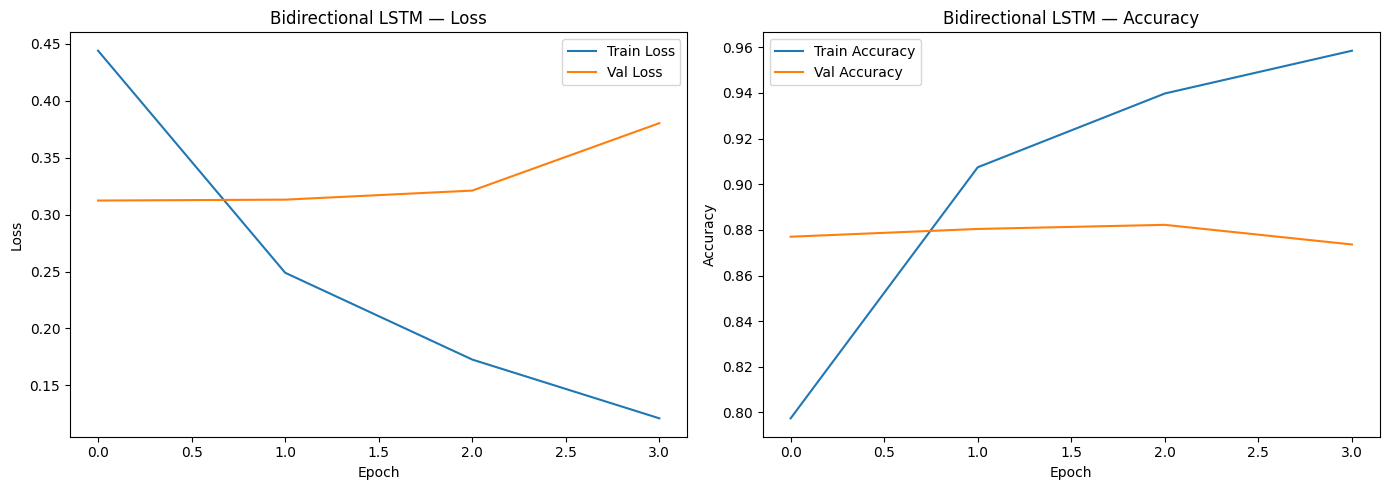

In [ ]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'],     label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[0].set_title("Bidirectional LSTM — Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("Bidirectional LSTM — Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate**

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
=== Bidirectional LSTM — Test Evaluation ===

              precision    recall  f1-score   support

    Negative       0.92      0.83      0.87      4961
    Positive       0.85      0.93      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



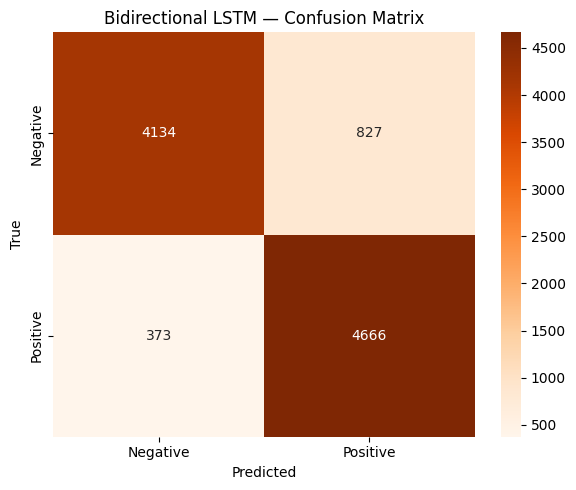

In [ ]:
# Evaluate
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

print("=== Bidirectional LSTM — Test Evaluation ===\n")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Bidirectional LSTM — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

**Model 3: LSTM with Word2Vec**

**Install & Train Word2Vec**

In [ ]:
pip install gensim

In [ ]:
from gensim.models import Word2Vec

# Tokenize cleaned text into list of word lists
train_sentences = [text.split() for text in train_df['cleaned']]

# Train Word2Vec on training data
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=128,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print(f"Sample vector for 'film': {w2v_model.wv['film'][:5]}")

Word2Vec vocabulary size: 55234
Sample vector for 'film': [0.20329179 1.5988972  1.1302887  0.31531498 0.47629312]


**Build Embedding Matrix**

In [ ]:
import numpy as np

EMBED_DIM_W2V = 128

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))

word_index = tokenizer.word_index
found = 0

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            found += 1

print(f"Words found in Word2Vec: {found} / {min(VOCAB_SIZE, len(word_index))}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in Word2Vec: 19998 / 20000
Embedding matrix shape: (20000, 128)


**Build Model 3**

In [ ]:
from tensorflow.keras.layers import Bidirectional, LSTM, Embedding, Dense, Dropout
from tensorflow.keras.models import Sequential

model_w2v = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM_W2V,
              weights=[embedding_matrix],   # pretrained weights
              input_length=MAX_LEN,
              trainable=False),             # freeze embedding layer
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,560,000 (9.77 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,560,000 (9.77 MB)

**Train**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)
w2v_time = time.time() - start
print(f"Word2Vec LSTM Training time: {w2v_time:.2f}s")

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 36s 108ms/step - accuracy: 0.8123 - loss: 0.4321 - val_accuracy: 0.8454 - val_loss: 0.3750
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.8655 - loss: 0.3241 - val_accuracy: 0.8824 - val_loss: 0.2826
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.8822 - loss: 0.2883 - val_accuracy: 0.8864 - val_loss: 0.2773
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.8911 - loss: 0.2663 - val_accuracy: 0.8902 - val_loss: 0.2609
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9044 - loss: 0.2431 - val_accuracy: 0.8958 - val_loss: 0.2536
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.9133 - loss: 0.2195 - val_accuracy: 0.8982 - val_loss: 0.2504
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.9222 - loss: 0.1953 - val_accuracy: 0.8940 - val_loss: 0.2629
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.9343 - loss: 0.1678 -

**Plot**

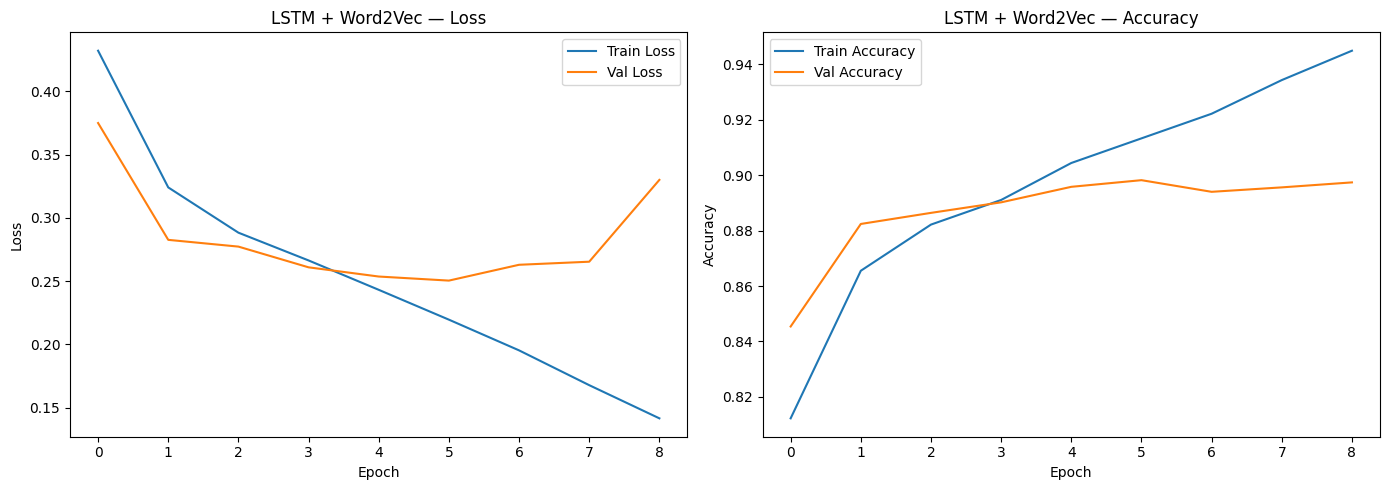

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v.history['loss'],     label='Train Loss')
axes[0].plot(history_w2v.history['val_loss'], label='Val Loss')
axes[0].set_title("LSTM + Word2Vec — Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history_w2v.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_w2v.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("LSTM + Word2Vec — Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate**

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
=== LSTM + Word2Vec — Test Evaluation ===

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      4961
    Positive       0.90      0.90      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



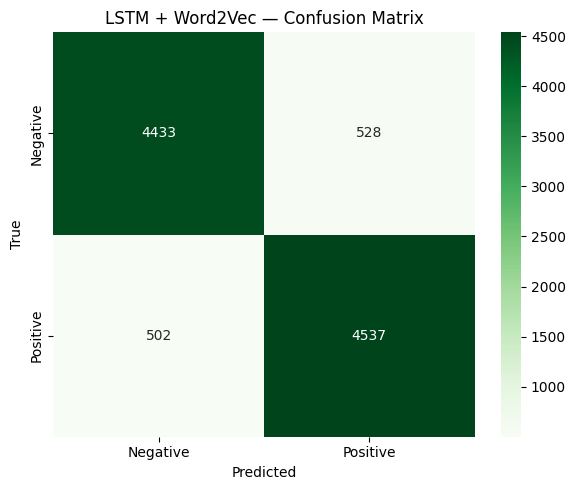

In [ ]:
y_pred_w2v = (model_w2v.predict(X_test_pad) > 0.5).astype(int)

print("=== LSTM + Word2Vec — Test Evaluation ===\n")
print(classification_report(y_test, y_pred_w2v, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("LSTM + Word2Vec — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

**Model Comaparison**

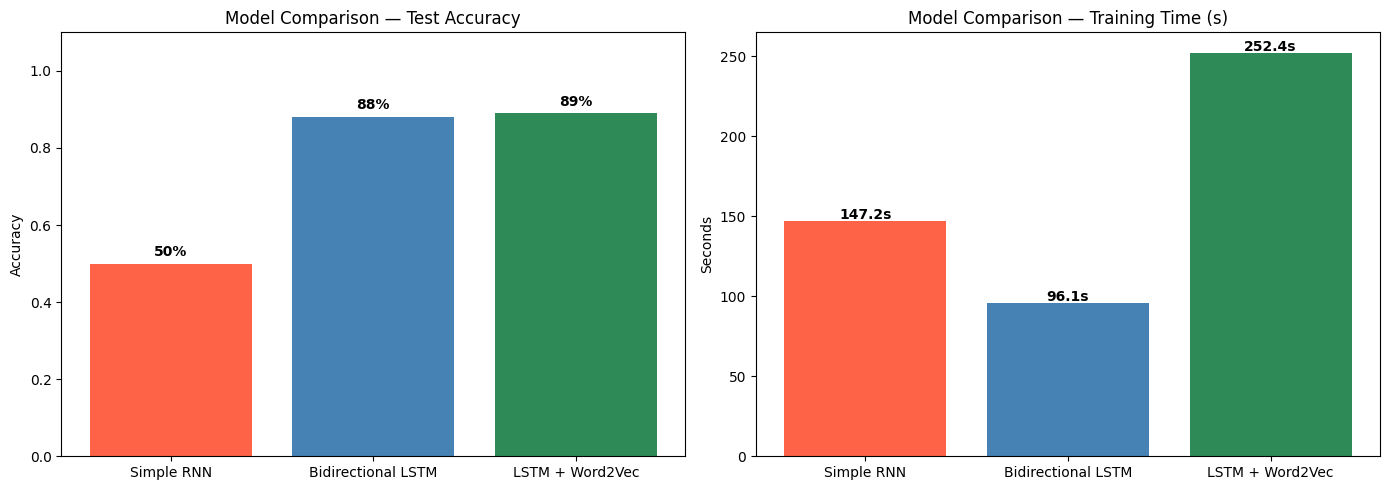

Model                       Accuracy       Time
Simple RNN                       50%    147.21s
Bidirectional LSTM               88%     96.06s
LSTM + Word2Vec                  89%    252.37s


In [ ]:
# Comparison bar chart
models_names = ['Simple RNN', 'Bidirectional LSTM', 'LSTM + Word2Vec']
accuracies   = [0.50, 0.88, 0.89]
times        = [rnn_time, lstm_time, w2v_time]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
bars = axes[0].bar(models_names, accuracies, color=['tomato', 'steelblue', 'seagreen'])
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Model Comparison — Test Accuracy")
axes[0].set_ylabel("Accuracy")
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.0%}', ha='center', fontweight='bold')

# Training Time
bars2 = axes[1].bar(models_names, times, color=['tomato', 'steelblue', 'seagreen'])
axes[1].set_title("Model Comparison — Training Time (s)")
axes[1].set_ylabel("Seconds")
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{t:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Time':>10}")
print("=" * 55)
print(f"{'Simple RNN':<25} {'50%':>10} {rnn_time:>9.2f}s")
print(f"{'Bidirectional LSTM':<25} {'88%':>10} {lstm_time:>9.2f}s")
print(f"{'LSTM + Word2Vec':<25} {'89%':>10} {w2v_time:>9.2f}s")
print("=" * 55)

**Error Analysis**

In [ ]:
# Get misclassified examples from best model (Word2Vec)
test_df_reset = test_df.reset_index(drop=True)
misclassified = test_df_reset[y_pred_w2v.flatten() != y_test]

print(f"Total misclassified: {len(misclassified)} / {len(y_test)}\n")
print("=" * 70)

# Show 3 misclassified examples
for i, (idx, row) in enumerate(misclassified.head(3).iterrows()):
    true_label = 'Positive' if row['sentiment'] == 1 else 'Negative'
    pred_label = 'Positive' if y_pred_w2v[idx] == 1 else 'Negative'
    print(f"Example {i+1}:")
    print(f"  True Label : {true_label}")
    print(f"  Predicted  : {pred_label}")
    print(f"  Review     : {row['review'][:200]}...")
    print("=" * 70)

Total misclassified: 1030 / 10000

Example 1:
  True Label : Positive
  Predicted  : Negative
  Review     : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...
Example 2:
  True Label : Positive
  Predicted  : Negative
  Review     : Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV...
Example 3:
  True Label : Positive
  Predicted  : Negative
  Review     : I was first introduced to John Waters films by seeing "Female trouble" on IFC. I was disgusted but for some sick reason i enjoyed it. Then, i picked up the Pink Flamingos DVD in the John Waters Boxed ...


Gradio GUI

In [ ]:
!pip install gradio==3.50.2

In [ ]:
!pip install rfc3987

import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review_text):
    # Clean the input
    cleaned = clean_text(review_text)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict using best model (Word2Vec LSTM)
    prob = model_w2v.predict(padded, verbose=0)[0][0]
    label = "Positive " if prob > 0.5 else "Negative "
    confidence = prob if prob > 0.5 else 1 - prob

    return {
        "Sentiment": label,
        "Confidence": f"{confidence * 100:.2f}%",
        "Raw Score": f"{prob:.4f}"
    }

# Build Gradio interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.JSON(label="Prediction Result"),
    title="Movie Sentiment Analyzer",
    description="Enter a movie review and the LSTM + Word2Vec model will predict whether it is Positive or Negative.",
    examples=[
        ["This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout."],
        ["Terrible film. Waste of time and money. The plot made no sense and the acting was awful."],
        ["I was disgusted but for some sick reason I really enjoyed it. Brilliant yet disturbing."]
    ]
)

interface.launch()

IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://f684f213734f17a0b9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
